In [1]:

import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib 

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Set visual theme
sns.set_theme(style="darkgrid")
warnings.filterwarnings('ignore')

print("Pipeline dependencies loaded.")

Pipeline dependencies loaded.


In [2]:
# Data Ingestion and Cleaning Pipeline
def load_and_clean_data(filepath):
    """Loads e-commerce data and applies standard cleaning operations."""
    print("Loading dataset...")
    df = pd.read_csv(r"C:\AHAMMED\AI-Powered E-commerce Customer Intelligence System\Dataset\data.csv", encoding="latin1")
    
    initial_shape = df.shape
    
    # 1. Drop missing CustomerIDs
    df.dropna(subset=['CustomerID'], inplace=True)
    
    # 2. Remove duplicate rows
    df.drop_duplicates(inplace=True)
    
    # 3. Filter out negative quantities and prices (returns/errors)
    df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
    
    # 4. Correct Data Types
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
    df['CustomerID'] = df['CustomerID'].astype(int).astype(str)
    
    final_shape = df.shape
    print(f"Data cleaned. Rows reduced from {initial_shape[0]} to {final_shape[0]}.")
    
    return df

# Execute (Adjust the path if your notebook is in the notebooks/ folder)
df_clean = load_and_clean_data(r"C:\AHAMMED\AI-Powered E-commerce Customer Intelligence System\Dataset\data.csv")

Loading dataset...
Data cleaned. Rows reduced from 541909 to 392692.


In [3]:
# Cell 3: Feature Engineering (RFM Matrix)
def engineer_rfm_features(df):
    """Aggregates transactional data into a Customer RFM matrix."""
    df_copy = df.copy()
    df_copy['TotalAmount'] = df_copy['Quantity'] * df_copy['UnitPrice']
    
    # Establish snapshot date
    snapshot_date = df_copy['InvoiceDate'].max() + dt.timedelta(days=1)
    
    # Aggregate to RFM
    rfm = df_copy.groupby('CustomerID').agg({
        'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
        'InvoiceNo': 'nunique',
        'TotalAmount': 'sum'
    }).reset_index()
    
    rfm.rename(columns={
        'InvoiceDate': 'Recency',
        'InvoiceNo': 'Frequency',
        'TotalAmount': 'Monetary'
    }, inplace=True)
    
    print(f"RFM matrix generated for {rfm.shape[0]} unique customers.")
    return rfm

rfm_matrix = engineer_rfm_features(df_clean)

RFM matrix generated for 4338 unique customers.


In [4]:
# Cell 4: Preprocessing for Clustering
def preprocess_for_clustering(rfm_df):
    """Applies log transformation and standard scaling to RFM features."""
    # Extract the numerical columns
    rfm_features = rfm_df[['Recency', 'Frequency', 'Monetary']].copy()
    
    # Log transformation to handle right-skewed e-commerce data (add 1 to avoid log(0))
    rfm_log = np.log(rfm_features + 1)
    
    # Standardize to mean=0 and variance=1
    scaler = StandardScaler()
    rfm_scaled = scaler.fit_transform(rfm_log)
    
    # Convert back to DataFrame
    rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm_df.index, columns=rfm_features.columns)
    
    print("Data successfully transformed and scaled.")
    return rfm_scaled_df, scaler

rfm_scaled_df, scaler = preprocess_for_clustering(rfm_matrix)

Data successfully transformed and scaled.


In [5]:
# Cell 5: Algorithm Comparison
def evaluate_clustering_algorithms(scaled_data):
    """Evaluates K-Means, Hierarchical, and DBSCAN clustering models."""
    print("Evaluating clustering algorithms...\n")
    
    # 1. K-Means (Using k=4 based on previous Elbow Method analysis)
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(scaled_data)
    kmeans_score = silhouette_score(scaled_data, kmeans_labels)
    print(f"1. K-Means Silhouette Score: {kmeans_score:.4f}")
    
    # 2. Hierarchical Clustering (Agglomerative)
    hc = AgglomerativeClustering(n_clusters=4)
    hc_labels = hc.fit_predict(scaled_data)
    hc_score = silhouette_score(scaled_data, hc_labels)
    print(f"2. Hierarchical Clustering Silhouette Score: {hc_score:.4f}")
    
    # 3. DBSCAN (Density-based)
    # DBSCAN requires tuning eps and min_samples. It often struggles with varying density RFM data.
    dbscan = DBSCAN(eps=0.5, min_samples=10)
    dbscan_labels = dbscan.fit_predict(scaled_data)
    
    # DBSCAN might group everything into noise (-1) or a single cluster if not tuned perfectly
    if len(set(dbscan_labels)) > 1:
        dbscan_score = silhouette_score(scaled_data, dbscan_labels)
        print(f"3. DBSCAN Silhouette Score: {dbscan_score:.4f}")
    else:
        print("3. DBSCAN failed to find distinct clusters (only 1 cluster or noise found).")
        
    return kmeans_labels

# Execute comparison and store the winning labels (K-Means)
best_labels = evaluate_clustering_algorithms(rfm_scaled_df)

# Attach the winning labels back to the original dataset and assign business personas
rfm_matrix['Cluster'] = best_labels
persona_map = {0: 'Champions', 1: 'Lost/Churned', 2: 'New/Promising', 3: 'Loyal/Regulars'}
rfm_matrix['Persona'] = rfm_matrix['Cluster'].map(persona_map)

Evaluating clustering algorithms...

1. K-Means Silhouette Score: 0.3375
2. Hierarchical Clustering Silhouette Score: 0.2800
3. DBSCAN Silhouette Score: 0.2662


In [6]:
# Cell 6: Predictive Classifier (Random Forest)
print("Initializing Predictive Pipeline...\n")

# Define Features (X) and Target (y)
X = rfm_matrix[['Recency', 'Frequency', 'Monetary']]
y = rfm_matrix['Persona']

# Split into training (80%) and testing (20%) sets
# stratify=y ensures the same proportion of segments in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Random Forest
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Initializing Predictive Pipeline...

Model Accuracy: 97.35%

Classification Report:
                precision    recall  f1-score   support

     Champions       0.97      0.98      0.98       143
  Lost/Churned       0.99      0.98      0.98       325
Loyal/Regulars       0.96      0.98      0.97       233
 New/Promising       0.96      0.96      0.96       167

      accuracy                           0.97       868
     macro avg       0.97      0.97      0.97       868
  weighted avg       0.97      0.97      0.97       868



Feature Importance:
           Importance
Recency      0.413407
Monetary     0.308383
Frequency    0.278210


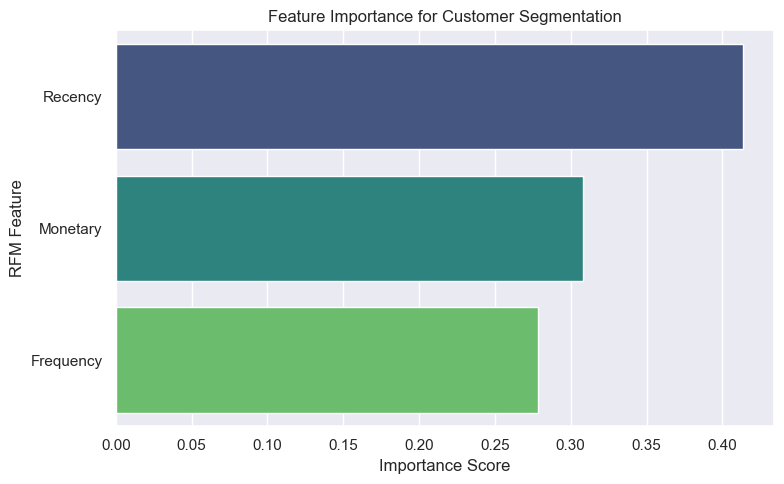


Model successfully packaged and saved to ../models/customer_segmentation_rf_model.pkl


In [7]:
# Cell 7: Feature Importance & Model Export

# Calculate and display feature importance
feature_importances = pd.DataFrame(
    rf_classifier.feature_importances_, 
    index=X.columns, 
    columns=['Importance']
).sort_values(by='Importance', ascending=False)

print("Feature Importance:")
print(feature_importances)

# Plot feature importance
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importances['Importance'], y=feature_importances.index, palette='viridis')
plt.title('Feature Importance for Customer Segmentation')
plt.xlabel('Importance Score')
plt.ylabel('RFM Feature')
plt.tight_layout()
plt.show()

# Export the trained model to the models folder
model_filename = '../models/customer_segmentation_rf_model.pkl'
joblib.dump(rf_classifier, model_filename)
print(f"\nModel successfully packaged and saved to {model_filename}")

In [8]:
# Export Data for Power BI
import os

os.makedirs('../deliverables/powerbi_data', exist_ok=True)

# 1. Export Customer-Level RFM & Segment Matrix
rfm_matrix.to_csv('../deliverables/powerbi_data/rfm_segmented_customers.csv', index=False)

# 2. Merge Persona back to transactional data for drill-down analysis
df_enriched = df_clean.merge(rfm_matrix[['CustomerID', 'Persona']], on='CustomerID', how='left')
df_enriched.to_csv('../deliverables/powerbi_data/enriched_transactions.csv', index=False)

print("Power BI datasets exported successfully to 'deliverables/powerbi_data/'.")

Power BI datasets exported successfully to 'deliverables/powerbi_data/'.
